# <font color=blue>Filtros y Suavizado</font>


Este notebook proporciona las bases necesarias para trabajar con la biblioteca OpenCV en Python para aplicar filtros o suavizado para mejorar y eliminar ruido en imagenes.

## <font color="#F20C60">Filtro Gaussiano</font>

Es el resultado de desenfocar una imagen mediante una función gaussiana. Es un efecto muy utilizado en software de gráficos, normalmente para reducir el ruido de la imagen y los detalles. También se utiliza como etapa de preprocesamiento antes de aplicar nuestros modelos de aprendizaje automático o de aprendizaje profundo. Por ejemplo, un kernel gaussiano (3×3). Para mas información puedes dar clic [aqui.](https://docs.opencv.org/3.4/dc/dd3/tutorial_gausian_median_blur_bilateral_filter.html)

### <font color=green> Sintaxis Básica </font>
``` python
out = cv2.GaussianBlur(src, Ksize, sigmaX, sigmaY)
```

1. `src `: Imagen de entrada.

2. `ksize (tupla)`: Tamaño del kernel gaussiano (debe ser impar).

3. `sigmaX`: Desviación estándar en la dirección X.

4. `sigmaY`: Desviación estándar en la dirección Y (si no se proporciona, se toma igual a sigmaX).

5. `out`: Imagen con filtro.


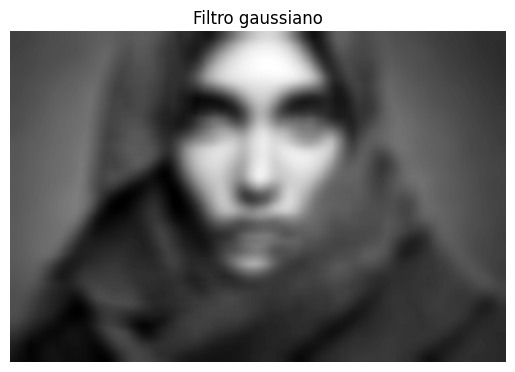

In [ ]:
blurred = cv2.GaussianBlur(img, (21,21), 10.0)

## <font color="#F20C60">Filtro Simple</font>

Aplica un filtro de promediado, útil para reducir el ruido en una imagen.

### <font color=green> Sintaxis Básica </font>
``` python
out = cv2.blur(src, ksize)
```

1. `src `: Imagen de entrada.

2. `ksize (tupla)`: Tamaño del kernel (Mayor a 1).

3. `out`: Imagen con filtro.

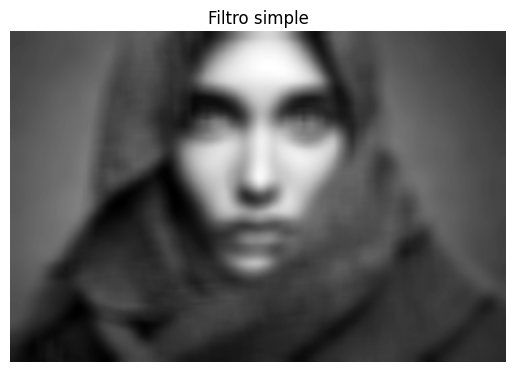

In [ ]:
blurred = cv2.blur(img, (16,16))

## <font color="#F20C60">Filtro de Media</font>

Es una técnica de filtrado digital no lineal que se utiliza a menudo para eliminar el ruido de una imagen o señal. El filtrado medio se utiliza mucho en el procesamiento de imágenes digitales porque, en determinadas condiciones, conserva los bordes a la vez que elimina el ruido. Es uno de los mejores algoritmos para eliminar el ruido de sal y pimienta. Para mas información puedes dar clic [aqui.](https://docs.opencv.org/3.4/dc/dd3/tutorial_gausian_median_blur_bilateral_filter.html)

### <font color=green> Sintaxis Básica </font>
``` python
out = cv2.medianBlur(src, ksize)
```

1. `src `: Imagen de entrada.

2. `ksize`: Tamaño del kernel (debe ser impar y mayor que 1).

3. `out`: Imagen con filtro.

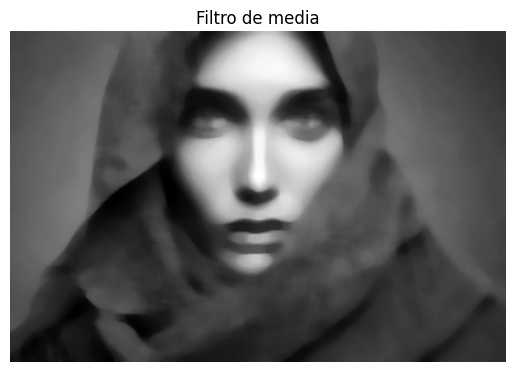

In [ ]:
media = cv2.medianBlur(img, 13)

## <font color="#F20C60">Filtro Bilateral</font>

Es un filtro suavizador de imágenes no lineal que conserva los bordes y reduce el ruido. Reemplaza la intensidad de cada píxel con un promedio ponderado de los valores de intensidad de los píxeles cercanos. Este peso puede basarse en una distribución gaussiana. De este modo, se conservan los bordes nítidos y se descartan los débiles.

### <font color=green> Sintaxis Básica </font>
``` python
out = cv2.bilateralFilter(src, d, sigmaColor, sigmaSpace)
```

1. `src `: Imagen de entrada.

2. `ksize`: Tamaño del área de los píxeles usados en el filtro.

3. `sigmaColor`: Filtro en el espacio de colores.

4. `sigmaSpace`: Filtro en el espacio de coordenadas.

5. `out`: Imagen con filtro.

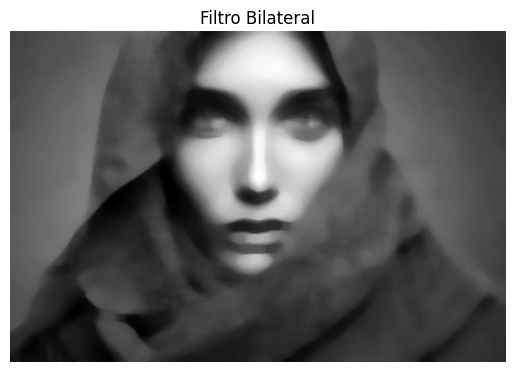

In [ ]:
blurred = cv2.bilateralFilter(img, 9, 75, 75)

## <font color="#F20C60">Metodos de numpy para filtros de Fourier</font>

Estos metodos de numpy nos ayudan en el calculo de la transformada discreta de fourier, como tambien para obtener el logaritmo natural que se utiliza en algunos filtros.

### <font color="#770EB2">Transformada Rápida de Fourier</font>

Esta función calcula la transformada de Fourier discreta de `n` dimensiones sobre cualquier eje en una matriz de `M` dimensiones mediante la transformada rápida de Fourier `(FFT)`. De manera predeterminada, la transformada se calcula sobre los dos últimos ejes de la matriz de entrada, es decir, una `FFT` bidimensional. Para mas información puedes dar clic [aqui.](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft2.html)

### <font color=green> Sintaxis Básica </font>
``` python
val = np.fft.fft2(a, s = None, axes =(-2,-1), norm = None)
```

1. `a `: Matriz de entrada, en este caso nuestra imagen.

2. `s`: secuencia de ints, opcional

3. `axes`: ejes de números enteros, opcional

4. `norm`: Modo de normalización. El valor predeterminado es “hacia atrás”, opcional.

5. `val`: es el valor obtenido de la transformada.

In [ ]:
dft = np.fft.fft2(img)

### <font color="#770EB2">Desplazar el componente de frecuencia</font>

Desplazar el componente de frecuencia cero al centro del espectro.

Esta función intercambia los medios espacios de todos los ejes enumerados (el valor predeterminado es todos). Tenga en cuenta que `y[0]`es el componente de Nyquist solo si `len(x)`es par. Para mas información puedes dar clic [aqui.](https://numpy.org/doc/2.2/reference/generated/numpy.fft.fftshift.html)

### <font color=green> Sintaxis Básica </font>
``` python
val = np.fft.fftshift(x, ejes = None)
```

1. `x`: Matriz de entrada, en este caso nuestro resultado de la transformada.

2. `eje`: Ejes sobre los que se realizará el desplazamiento. El valor predeterminado es Ninguno, que desplaza todos los ejes.

3.  `val`: La matriz desplazada.


In [ ]:
dft_shift = np.fft.fftshift(dft)

### <font color="#770EB2">Cálculo de logaritmos</font>

Calcula el logaritmo natural de los elementos de un array, útil para la visualización de espectros de Fourier.  Para mas información puedes dar clic [aqui.](https://numpy.org/doc/2.1/reference/generated/numpy.log.html)

### <font color=green> Sintaxis Básica </font>
``` python
val = np.log(x, out=None, *, where=True)
```

1. `x`: Valor de entrada.En nuestro caso el componente de frecuencia desplazado.

2. `out`: Ubicación en la que se almacena el resultado. Si se proporciona, debe tener una forma a la que se transmitan las entradas. Si no se proporciona, se devuelve una matriz recién asignada, debe tener una longitud igual a la cantidad de salidas.

3.  `where`: Esta condición se transmite por la entrada. En las ubicaciones donde la condición es Verdadera, la matriz de salida se establecerá en el resultado de ufunc. En el resto de los casos, la matriz de salida conservará su valor original.

4.  `val`: La salida obtenida del logaritmo.

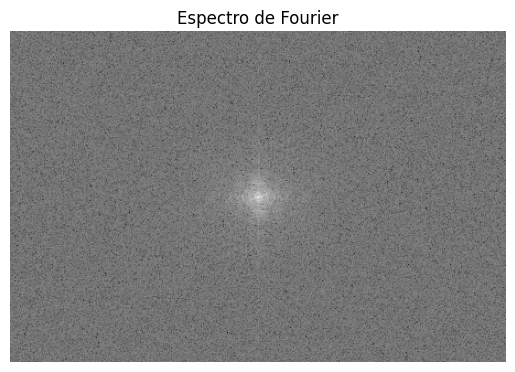

In [ ]:
log_img = 20 * np.log(np.abs(dft_shift))